# Customer Segmentation Using Clustering Techniques

**Objective:** Discover actionable RFM-style customer groups using multiple clustering diagnostics and portable data generation.

The deterministic demo data contains hidden generator profiles for post-hoc diagnostics. Those profiles are never supplied to the clustering algorithms.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic domain-shaped data


In [2]:
FEATURES = ["recency_days", "orders_12m", "annual_spend", "avg_order_value", "return_rate", "engagement_score"]
PROFILE_CENTERS = {
  "champions": [
    12,
    28,
    5200,
    190,
    0.05,
    88
  ],
  "loyal": [
    35,
    17,
    2900,
    165,
    0.08,
    70
  ],
  "at_risk": [
    140,
    7,
    1300,
    185,
    0.16,
    35
  ],
  "new_value": [
    24,
    4,
    720,
    175,
    0.1,
    58
  ]
}
rows = []
for profile, centers in PROFILE_CENTERS.items():
    centers = np.asarray(centers, dtype=float)
    scales = np.maximum(np.abs(centers) * 0.10, 0.08)
    samples = rng.normal(centers, scales, size=(125, len(FEATURES)))
    samples = np.maximum(samples, 0)
    for row in samples:
        rows.append({**dict(zip(FEATURES, row)), "generator_profile": profile})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
for column in FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=8, replace=False)
    data.loc[missing_rows, column] = np.nan
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset shape: 500 rows × 7 columns


,recency_days,orders_12m,annual_spend,avg_order_value,return_rate,engagement_score,generator_profile
0,179.377,5.804,1204.011,173.601,0.092,31.228,at_risk
1,11.215,29.198,5101.593,196.245,0.079,99.622,champions
2,146.892,6.566,1094.318,171.224,0.156,39.080,at_risk
3,35.021,17.762,3237.939,192.182,0.105,74.127,loyal
4,12.565,26.506,4985.948,215.890,0.000,66.768,champions


,count,mean,std,min,25%,50%,75%,max
recency_days,492.0,52.453,50.391,8.443,19.614,28.321,106.213,179.377
orders_12m,492.0,13.977,9.515,2.774,5.553,9.899,21.830,36.159
annual_spend,500.0,2523.811,1770.441,548.396,976.240,1904.928,3712.994,6710.635
avg_order_value,500.0,179.202,20.117,116.232,165.245,178.548,194.019,234.225
return_rate,500.0,0.102,0.075,0.000,0.039,0.097,0.157,0.351
engagement_score,500.0,62.589,20.162,24.790,44.588,63.024,77.043,110.860


## 3. Robust preprocessing and cluster-count selection


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
X = preprocessor.fit_transform(data[FEATURES])
selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection_rows.append({"k": k, "silhouette": silhouette_score(X, labels), "davies_bouldin": davies_bouldin_score(X, labels)})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))
best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} by maximum silhouette score.")


Selected k=2 by maximum silhouette score.


,k,silhouette,davies_bouldin
0,2,0.6515,0.4808
1,3,0.5005,0.7666
2,4,0.4627,0.9357
3,5,0.4448,0.9630
4,6,0.4028,1.1024


## 4. Compare algorithms and retain the clearer solution


In [4]:
kmeans = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)
hierarchical_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X)

comparison = pd.DataFrame([
    {"model": "K-Means", "silhouette": silhouette_score(X, kmeans_labels), "davies_bouldin": davies_bouldin_score(X, kmeans_labels)},
    {"model": "Agglomerative", "silhouette": silhouette_score(X, hierarchical_labels), "davies_bouldin": davies_bouldin_score(X, hierarchical_labels)},
])
display(comparison.round(4))
labels = kmeans_labels if comparison.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["model"] == "K-Means" else hierarchical_labels
selected_model = "K-Means" if np.array_equal(labels, kmeans_labels) else "Agglomerative"
data["cluster"] = labels
print(f"Selected solution: {selected_model}")


Selected solution: K-Means


,model,silhouette,davies_bouldin
0,K-Means,0.6515,0.4808
1,Agglomerative,0.6515,0.4808


## 5. Profile and visualize the discovered groups


Retrospective ARI against hidden generator profiles: 0.3261


,records,recency_days,orders_12m,annual_spend,avg_order_value,return_rate,engagement_score
cluster,,,,,,,
0,376,23.895,16.343,2931.094,177.604,0.086,71.851
1,124,137.207,6.957,1288.823,184.048,0.153,34.505


cluster,0,1,All
generator_profile,,,
at_risk,1,124,125
champions,125,0,125
loyal,125,0,125
new_value,125,0,125
All,376,124,500


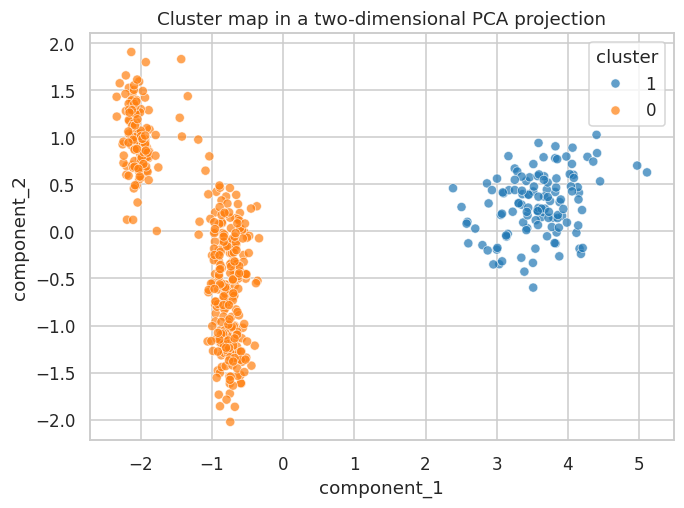

In [5]:
from sklearn.decomposition import PCA

profiles = data.groupby("cluster")[FEATURES].mean().round(3)
profiles.insert(0, "records", data.groupby("cluster").size())
display(profiles)
display(pd.crosstab(data["generator_profile"], data["cluster"], margins=True))
print(f"Retrospective ARI against hidden generator profiles: {adjusted_rand_score(data['generator_profile'], data['cluster']):.4f}")

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("Cluster map in a two-dimensional PCA projection")
plt.tight_layout()
plt.show()


## 6. Stability and assignment example


In [6]:
alternate = KMeans(n_clusters=best_k, n_init=40, random_state=7).fit_predict(X)
print(f"K-Means stability across seeds (ARI): {adjusted_rand_score(kmeans_labels, alternate):.4f}")
if selected_model == "K-Means":
    example = data[FEATURES].median().to_frame().T
    predicted = int(kmeans.predict(preprocessor.transform(example))[0])
    display(example.round(3).assign(predicted_cluster=predicted))
else:
    print("Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.")


K-Means stability across seeds (ARI): 1.0000


,recency_days,orders_12m,annual_spend,avg_order_value,return_rate,engagement_score,predicted_cluster
0,28.321,9.899,1904.928,178.548,0.097,63.024,0


## 7. Findings and limitations

- Multiple internal metrics and a seed-stability check are used because clustering has no single accuracy measure.
- Hidden generator profiles provide only a retrospective pipeline check.
- Production interpretation requires domain validation, drift monitoring, and explicit rules for acting on segments.
